In [79]:
import pandas as pd
import numpy as np

In [80]:
df = pd.read_excel('practica forecast ventas spm.xlsx', header=4, usecols="C:E")

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   producto  115 non-null    str  
 1   fecha     115 non-null    str  
 2   ventas    115 non-null    int64
dtypes: int64(1), str(2)
memory usage: 2.8 KB


In [81]:
#aqui tenemos un caso basico donde las fechas de los documentos están en español y python solo las lee en inglés
df['fecha']

0      Abr-2024
1      May-2024
2      Jun-2024
3      Jul-2024
4      Ago-2024
         ...   
110    Oct-2025
111    Nov-2025
112    Dic-2025
113    Ene-2026
114    Feb-2026
Name: fecha, Length: 115, dtype: str

In [82]:
#vamos a convertir los meses de español a inglés

months = {
    "ene" : "january",
    "feb" : "february",
    "mar" : "march",
    "abr" : "april",
    "may" : "may",
    "jun" : "june",
    "jul" : "july",
    "ago" : "august",
    "sep" : "september",
    "oct" : "october",
    "nov" : "november",
    "dic" : "december"
} 

dates = df['fecha'].astype(str).str.lower().str.strip().replace(months, regex=True)
df['fecha'] = pd.to_datetime(dates, format='mixed')


In [83]:
#confirmamos que ya esta en formato fecha
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   producto  115 non-null    str           
 1   fecha     115 non-null    datetime64[us]
 2   ventas    115 non-null    int64         
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 2.8 KB


### ¿Cuánto se ha vendido en total?

In [84]:
ventas_total = df['ventas'].sum()
print('el total de las ventas desde Abril 2024 hasta febrero 2026 es de:', ventas_total)
print('\n')
print(f'el promedio de ventas es de: {df['ventas'].mean():.2f}')

el total de las ventas desde Abril 2024 hasta febrero 2026 es de: 50529


el promedio de ventas es de: 439.38


### ¿Qué producto vende más?

In [85]:
ventas_producto = df.groupby('producto')['ventas'].sum().sort_values(ascending=False)

ventas_producto

producto
umckaloabo    25562
plantival      7737
enterokan      6977
vitanco        6655
tebonin        3598
Name: ventas, dtype: int64

<Axes: xlabel='producto'>

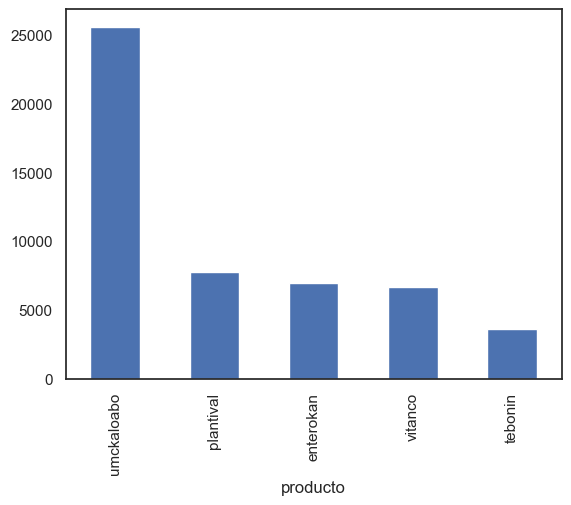

In [86]:
#aqui vamos a graficar de manera sencilla para darnos una idea a primera vista
ventas_producto.plot(kind='bar')

C:\Users\carlo\AppData\Local\Temp\ipykernel_16704\494953103.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='producto', y='ventas', ax=ax, palette="muted")


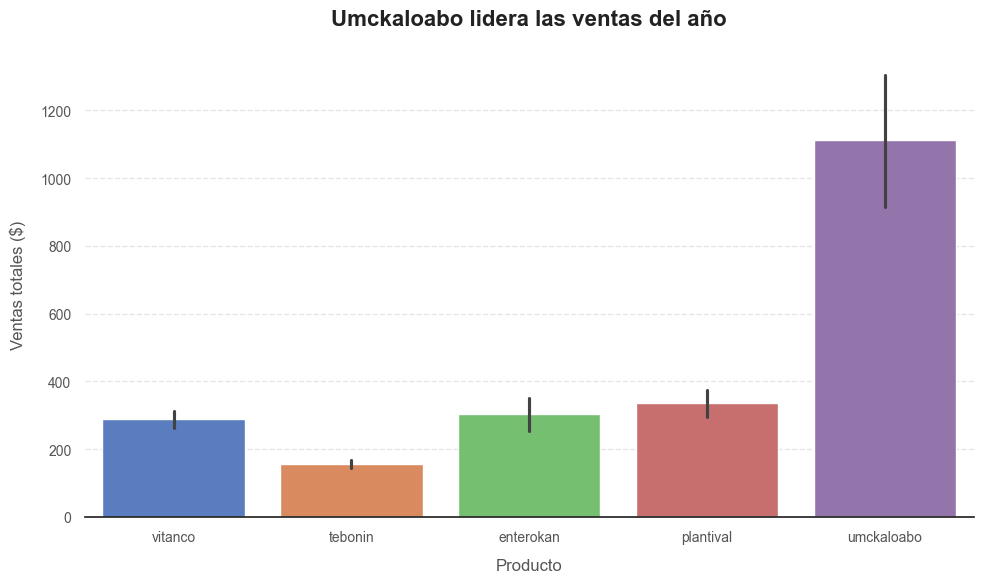

In [89]:
#aqui vamos a realizar un diseño para presentación de negocios

import matplotlib.pyplot as plt
import seaborn as sns

#Configuramos el estilo base y el tamaño del lienzo

sns.set_theme(style='white') #Fondo blanco limpio, sin bordes innecesarios
fig, ax = plt.subplots(figsize=(10,6), dpi=100)  #el dpi alto hace que se vea limpio

#2. paleta de colores con tonos profesionales
colores = ['"#2b5c8f", "#d95f02", "#7570b3"']

# 3.- Creamos la gráfica
sns.barplot(data=df, x='producto', y='ventas', ax=ax, palette="muted")

# 4.- El mandamiento de la limpieza: quitar los bordes superiores derecho e izquierdo
sns.despine(left=True, bottom=False)

#5.-Agregar las lineas de fondo horizontales pero muy sutiles
ax.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc')

#Titulos con jerarquía visual clara
ax.set_title("Umckaloabo lidera las ventas del año", fontsize=16, pad=20, weight='bold', color='#222222')
ax.set_xlabel("Producto", fontsize=12, color='#555555', labelpad=10)
ax.set_ylabel("Ventas totales ($)", fontsize=12, color="#555555", labelpad=10)

#ajustamos los parametros de los ejes para que no compitan
ax.tick_params(colors='#555555', labelsize=10)

plt.tight_layout()
plt.show()


### ¿Que producto vende menos?

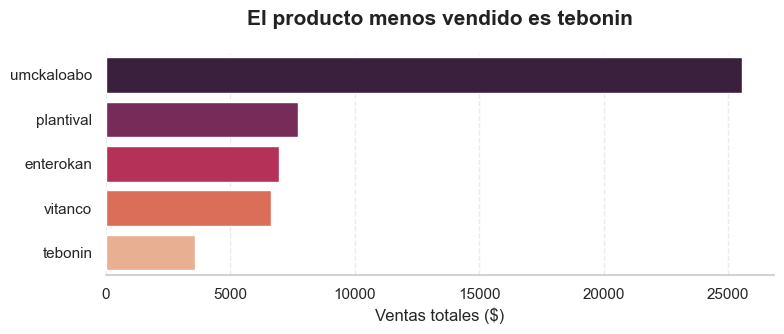

In [100]:
#aunque con la gráfica anterior podemos determinar cual es el producto que menos se vende para fines tecnicos/prácticos lo visualizaremos de otra forma
ventas_ordenadas = df.groupby('producto')['ventas'].sum().reset_index().sort_values(by='ventas', ascending=False)

sns.set_theme(style = "whitegrid")
f,ax = plt.subplots(figsize = (8,3.5), dpi=100)


sns.barplot(data=ventas_ordenadas, x='ventas', y='producto', ax=ax, hue='producto', legend=False, palette="rocket")

sns.despine(left=True, bottom=False)

ax.grid(axis='x', linestyle='--', alpha=0.4, color='#cccccc')

ax.set_title("El producto menos vendido es tebonin", fontsize=15, pad=20, weight='bold', color='#222222')
ax.set_xlabel('Ventas totales ($)')
ax.set_ylabel("", fontsize=11)

plt.tight_layout()
plt.show()


### ¿Cómo evolucionan las ventas en el tiempo? (estamos creciendo o cayendo)

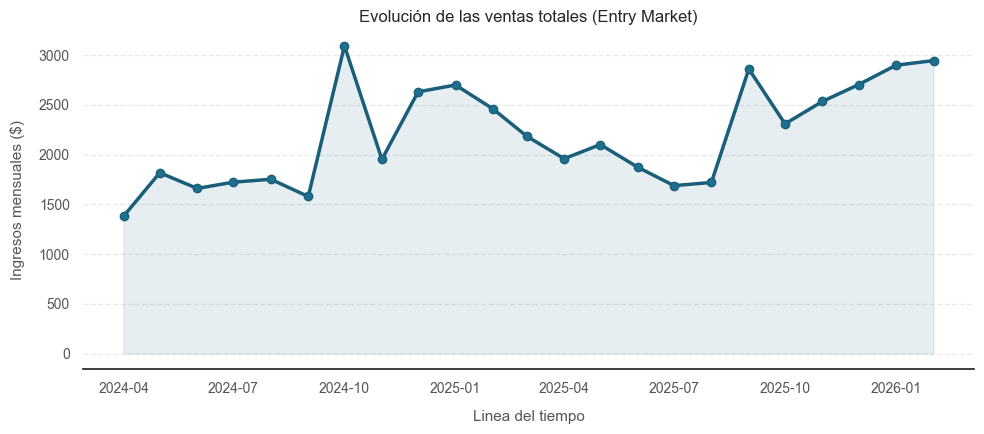

In [ ]:
ventas_fecha = df.groupby('fecha')['ventas'].sum()
ventas_fecha

sns.set_theme(style="white")
f, ax = plt.subplots(figsize = (10, 4.5), dpi=100)

ax.plot(
    ventas_fecha.index,
    ventas_fecha.values,
    color="#1a5f7a",
    linewidth = 2.5,
    marker='o',
    markersize = 6,
    markerfacecolor = "#1e7091"
)
#aquí es donde sicede la magia ya que se le añade el sombreado translúcido debajo de la linea
ax.fill_between(ventas_fecha.index, ventas_fecha.values, color="#1a5f7a", alpha=0.1)

#limpieza visual( en series de tiempo es mejor quitar el borde izquierdo y dear las guías horizaontales)
sns.despine(left=True, bottom=False)
ax.grid(axis='y', linestyle = '--', alpha=0.4, color='#cccccc')

#Titulos y etiquetas de centrado
ax.set_title("Evolución de las ventas totales (Entry Market)")
ax.set_xlabel("Linea del tiempo", fontsize=11, color="#555555", labelpad=10)
ax.set_ylabel("Ingresos mensuales ($)", fontsize=11, color="#555555", labelpad=10)

#Ajustar el color y el tamaño de los números en los ejes
ax.tick_params(colors="#555555", labelsize=10)

plt.tight_layout()
plt.show()

In [114]:
print(f"la fecha con mayor valor de ventas fue en: {ventas_fecha.idxmax()}")
print(f"la fecha con menor valor de ventas fue en: {ventas_fecha.idxmin()}")

la fecha con mayor valor de ventas fue en: 2024-10-01 00:00:00
la fecha con menor valor de ventas fue en: 2024-04-01 00:00:00


### ¿Las ventas son estables o muy variables?

In [120]:
producto_std = df.groupby('producto')['ventas'].std()
producto_std

producto
enterokan     117.008395
plantival     104.311482
tebonin        30.042131
umckaloabo    505.143700
vitanco        65.424216
Name: ventas, dtype: float64

Aqui determinamos la volatilidad de nuestros productos, el producto mas impredecible del catálogo es umckaloabo, y el producto ancla es tebonin, recordemos que tebonin es el producto que menos suma pero ahora descubrimos que lo poco que vende lo vende de forma constante y sin sobresaltos, es decir;

Aunque Umckaloabo genera altos volúmenes de ingreso, es un producto altamente volátil y de riesgo para el inventario ($\text{std} = 505$). Por otro lado, Tebonin representa nuestra línea más baja en ventas, pero ofrece el flujo más estable y predecible del portafolio ($\text{std} = 30$)

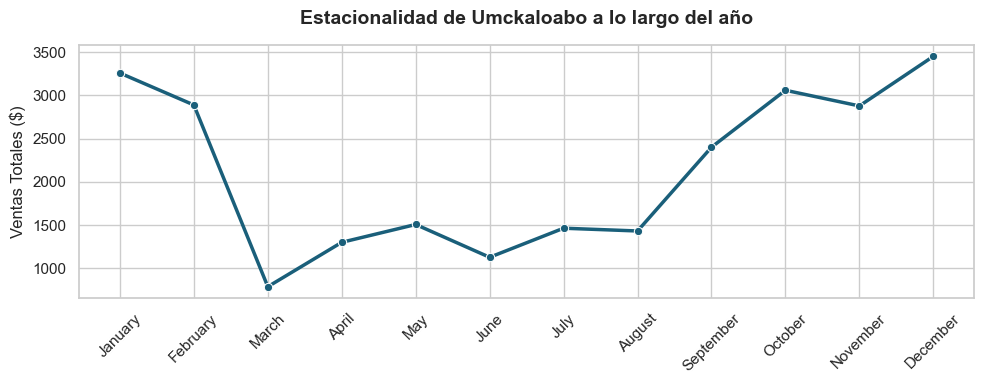

In [121]:
# 1. Extraemos el mes de nuestras fechas limpias
df['mes'] = df['fecha'].dt.strftime('%B')

# 2. Filtramos solo para Umckaloabo y agrupamos por mes
umck_estacional = df[df['producto'] == 'umckaloabo'].groupby('mes')['ventas'].sum()

# 3. Ordenamos los meses cronológicamente para que la gráfica tenga sentido
# (Crea una lista con el orden de los meses en inglés/español según tengas tus datos)
orden_meses = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
umck_estacional = umck_estacional.reindex(orden_meses)

# 4. Graficamos su comportamiento mensual
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 4), dpi=100)
sns.lineplot(x=umck_estacional.index, y=umck_estacional.values, marker='o', color='#1a5f7a', linewidth=2.5)
plt.title("Estacionalidad de Umckaloabo a lo largo del año", fontsize=14, weight='bold', pad=15)
plt.xticks(rotation=45)
plt.ylabel("Ventas Totales ($)")
plt.xlabel("")
plt.tight_layout()
plt.show()

### Con esta grafica previa los picos nos indicarían cuando abastecer los inventarios y los valles cuando frenar.